# Notebook 06 : Suivi Prédictif des Paiements 

**PFE 2026 - Malek - ESB**

## Objectif Business

**Question** : Quels clients vont **PAYER** leurs factures ?
Lesquels risquent de NE PAS payer ?

## 7 Algorithmes de Classification comparés

1. **Logistic Regression** : baseline (équivalent LR pour classif)
2. **KNN** avec **GridSearchCV** 
3. **SVM Classifier** (RBF kernel)
4. **Decision Tree Classifier**
5. **Random Forest Classifier**
6. **XGBoost Classifier**
7. **ANN (Artificial Neural Network)** TensorFlow

## Métriques d'évaluation

- **Accuracy** : pourcentage de bonnes prédictions
- **Precision** : précision sur les positifs
- **Recall** : rappel des vrais positifs
- **F1-Score** : moyenne harmonique
- **AUC** : aire sous la courbe ROC

## Démarche scientifique

1. Préparation des données (variable cible : va_payer)
2. Train/Test split (80/20 stratifié)
3. Entraînement des 7 modèles
4. Optimisation hyperparamètres (GridSearchCV)
5. Comparaison rigoureuse
6. Identification clients à risque

In [2]:
# === IMPORTS COMPLETS ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from pathlib import Path
from dotenv import load_dotenv
import os
import time

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)

# Algorithmes
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# XGBoost
import xgboost as xgb

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

# Configuration
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)

# Couleurs
COLOR_ORANGE = '#FF6600'
COLOR_GREEN = '#28A745'
COLOR_RED = '#DC3545'
COLOR_BLUE = '#0066CC'
COLOR_PURPLE = '#9C27B0'

np.random.seed(42)
tf.random.set_seed(42)

print("Bibliotheques chargees !")

Bibliotheques chargees !


In [3]:
# === CONNEXION POSTGRESQL ===

PROJECT_ROOT = Path.cwd().parent
load_dotenv(PROJECT_ROOT / ".env")

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

with engine.connect() as conn:
    result = conn.execute(text("SELECT 1")).fetchone()
print(f"Connexion OK : {result}")

Connexion OK : (1,)


In [4]:
# === CHARGEMENT DES DONNEES ===

query = """
SELECT 
    f.ventes_id,
    f.first_month_bill,
    f.second_month_bill,
    f.duree_engagement,
    b.canal_vente AS canal,
    b.entity_name AS boutique,
    b.region
FROM fact_ventes f
LEFT JOIN dim_boutique b ON f.boutique_key = b.boutique_key
WHERE f.first_month_bill IS NOT NULL;
"""

df = pd.read_sql(query, engine)

print(f"Nombre de contrats : {len(df):,}")
df.head()

Nombre de contrats : 60,458


,ventes_id,first_month_bill,second_month_bill,duree_engagement,canal,boutique,region
0,335635,1.0,1.0,25,FRANCHISE,Franchise Ksar Helal,None
1,335636,1.0,1.0,24,LAB2.0,LAB BEB JEDID,None
2,335637,1.0,1.0,24,PRO_VI,Agence Pro Franchise,None
3,335638,1.0,1.0,25,FRANCHISE,Franchise Korba,None
4,335639,1.0,1.0,24,FRANCHISE,Franchise Cite El Ghazella,None


In [5]:
# === CREATION DE LA CIBLE ===

# 1 = va payer, 0 = ne va pas payer
df['va_payer'] = (df['second_month_bill'].notna() & 
                  (df['second_month_bill'] > 0)).astype(int)

print(f"Distribution :")
print(df['va_payer'].value_counts())
print(f"\n  1 (Va payer)        : {(df['va_payer']==1).sum():,} ({(df['va_payer']==1).mean()*100:.1f}%)")
print(f"  0 (Ne va PAS payer) : {(df['va_payer']==0).sum():,} ({(df['va_payer']==0).mean()*100:.1f}%)")

Distribution :
va_payer
1    53837
0     6621
Name: count, dtype: int64

  1 (Va payer)        : 53,837 (89.0%)
  0 (Ne va PAS payer) : 6,621 (11.0%)


In [6]:
# === PREPARATION DES FEATURES ===

df = df.fillna({
    'duree_engagement': 0,
    'first_month_bill': 0,
    'canal': 'Non specifie',
    'boutique': 'Non specifie',
    'region': 'Non specifie'
})

features_cat = ['canal', 'boutique', 'region']
encoders = {}
df_encoded = df.copy()

for col in features_cat:
    le = LabelEncoder()
    df_encoded[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

features_num = ['first_month_bill', 'duree_engagement']
features_cat_encoded = [col + '_encoded' for col in features_cat]
features = features_num + features_cat_encoded

X = df_encoded[features].values
y = df_encoded['va_payer'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]:,} contrats")
print(f"Test  : {X_test.shape[0]:,} contrats")

Train : 48,366 contrats
Test  : 12,092 contrats


In [7]:
# === STRUCTURE POUR STOCKER LES RESULTATS ===

results_clf = []

def evaluate_classifier(name, y_true, y_pred, y_proba, training_time):
    """Evalue un modele de classification."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else 0
    
    results_clf.append({
        'Algorithme': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'AUC': auc,
        'Temps_s': training_time
    })
    
    print(f"\n>> {name}")
    print(f"   Accuracy  : {acc:.4f}")
    print(f"   Precision : {prec:.4f}")
    print(f"   Recall    : {rec:.4f}")
    print(f"   F1-Score  : {f1:.4f}")
    print(f"   AUC       : {auc:.4f}")
    print(f"   Temps     : {training_time:.2f}s")

print("Structure prete !")

Structure prete !


In [8]:
# === 1. LOGISTIC REGRESSION (Baseline) ===

print("Entrainement Logistic Regression...")

start = time.time()
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
elapsed = time.time() - start

evaluate_classifier('Logistic Regression', y_test, y_pred_lr, y_proba_lr, elapsed)

Entrainement Logistic Regression...

>> Logistic Regression
   Accuracy  : 0.9315
   Precision : 0.9341
   Recall    : 0.9931
   F1-Score  : 0.9627
   AUC       : 0.7348
   Temps     : 0.11s


In [9]:
# === 2. KNN AVEC GRIDSEARCHCV ===

print("Entrainement KNN avec GridSearchCV...")

start = time.time()
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train)
y_pred_knn = grid_knn.predict(X_test_scaled)
y_proba_knn = grid_knn.predict_proba(X_test_scaled)[:, 1]
elapsed = time.time() - start

print(f"\nMeilleurs hyperparametres : {grid_knn.best_params_}")
evaluate_classifier('KNN (GridSearch)', y_test, y_pred_knn, y_proba_knn, elapsed)

Entrainement KNN avec GridSearchCV...

Meilleurs hyperparametres : {'n_neighbors': 7, 'weights': 'uniform'}

>> KNN (GridSearch)
   Accuracy  : 0.9313
   Precision : 0.9343
   Recall    : 0.9927
   F1-Score  : 0.9626
   AUC       : 0.7589
   Temps     : 24.17s


In [10]:
# === 3. SVM CLASSIFIER ===

print("Entrainement SVM...")

start = time.time()
svm_clf = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm_clf.fit(X_train_scaled, y_train)
y_pred_svm = svm_clf.predict(X_test_scaled)
y_proba_svm = svm_clf.predict_proba(X_test_scaled)[:, 1]
elapsed = time.time() - start

evaluate_classifier('SVM (RBF)', y_test, y_pred_svm, y_proba_svm, elapsed)

Entrainement SVM...

>> SVM (RBF)
   Accuracy  : 0.9171
   Precision : 0.9357
   Recall    : 0.9739
   F1-Score  : 0.9544
   AUC       : 0.7424
   Temps     : 974.74s


In [11]:
# === 4. DECISION TREE ===

print("Entrainement Decision Tree...")

start = time.time()
dt = DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]
elapsed = time.time() - start

evaluate_classifier('Decision Tree', y_test, y_pred_dt, y_proba_dt, elapsed)

Entrainement Decision Tree...

>> Decision Tree
   Accuracy  : 0.8893
   Precision : 0.9374
   Recall    : 0.9383
   F1-Score  : 0.9379
   AUC       : 0.7963
   Temps     : 0.08s


In [12]:
# === 5. RANDOM FOREST ===

print("Entrainement Random Forest...")

start = time.time()
rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, 
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
elapsed = time.time() - start

evaluate_classifier('Random Forest', y_test, y_pred_rf, y_proba_rf, elapsed)

Entrainement Random Forest...

>> Random Forest
   Accuracy  : 0.9048
   Precision : 0.9373
   Recall    : 0.9571
   F1-Score  : 0.9471
   AUC       : 0.8070
   Temps     : 1.05s


In [13]:
# === 6. XGBOOST ===

print("Entrainement XGBoost...")

start = time.time()
xgb_clf = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, n_jobs=-1, eval_metric='logloss'
)
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]
elapsed = time.time() - start

evaluate_classifier('XGBoost', y_test, y_pred_xgb, y_proba_xgb, elapsed)

Entrainement XGBoost...

>> XGBoost
   Accuracy  : 0.9356
   Precision : 0.9338
   Recall    : 0.9984
   F1-Score  : 0.9650
   AUC       : 0.8118
   Temps     : 2.51s


In [14]:
# === 7. ANN (TensorFlow) ===

print("Entrainement ANN...")
print("Patience 1-2 minutes...")

start = time.time()

ann_clf = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')  # Classification binaire
])

ann_clf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_ann = ann_clf.fit(
    X_train_scaled, y_train,
    epochs=30, batch_size=32,
    validation_split=0.2, verbose=0
)

y_proba_ann = ann_clf.predict(X_test_scaled, verbose=0).flatten()
y_pred_ann = (y_proba_ann > 0.5).astype(int)

elapsed = time.time() - start

evaluate_classifier('ANN (Deep Learning)', y_test, y_pred_ann, y_proba_ann, elapsed)

Entrainement ANN...
Patience 1-2 minutes...

>> ANN (Deep Learning)
   Accuracy  : 0.9330
   Precision : 0.9329
   Recall    : 0.9965
   F1-Score  : 0.9636
   AUC       : 0.7836
   Temps     : 139.47s


In [15]:
# === TABLEAU COMPARATIF FINAL ===

df_results_clf = pd.DataFrame(results_clf)
df_results_clf = df_results_clf.sort_values('F1', ascending=False).reset_index(drop=True)
df_results_clf.insert(0, 'Rang', range(1, len(df_results_clf) + 1))

df_results_clf['Choix'] = ''
df_results_clf.loc[0, 'Choix'] = 'RETENU (TOP)'

print("CLASSEMENT FINAL DES 7 ALGORITHMES")
print("=" * 90)
print(df_results_clf.round(4).to_string(index=False))

print(f"\nMEILLEUR ALGORITHME : {df_results_clf.iloc[0]['Algorithme']}")
print(f"  - F1-Score : {df_results_clf.iloc[0]['F1']:.4f}")
print(f"  - AUC      : {df_results_clf.iloc[0]['AUC']:.4f}")

CLASSEMENT FINAL DES 7 ALGORITHMES
 Rang          Algorithme  Accuracy  Precision  Recall     F1    AUC  Temps_s        Choix
    1             XGBoost    0.9356     0.9338  0.9984 0.9650 0.8118   2.5092 RETENU (TOP)
    2 ANN (Deep Learning)    0.9330     0.9329  0.9965 0.9636 0.7836 139.4688             
    3 Logistic Regression    0.9315     0.9341  0.9931 0.9627 0.7348   0.1147             
    4    KNN (GridSearch)    0.9313     0.9343  0.9927 0.9626 0.7589  24.1723             
    5           SVM (RBF)    0.9171     0.9357  0.9739 0.9544 0.7424 974.7383             
    6       Random Forest    0.9048     0.9373  0.9571 0.9471 0.8070   1.0485             
    7       Decision Tree    0.8893     0.9374  0.9383 0.9379 0.7963   0.0802             

MEILLEUR ALGORITHME : XGBoost
  - F1-Score : 0.9650
  - AUC      : 0.8118


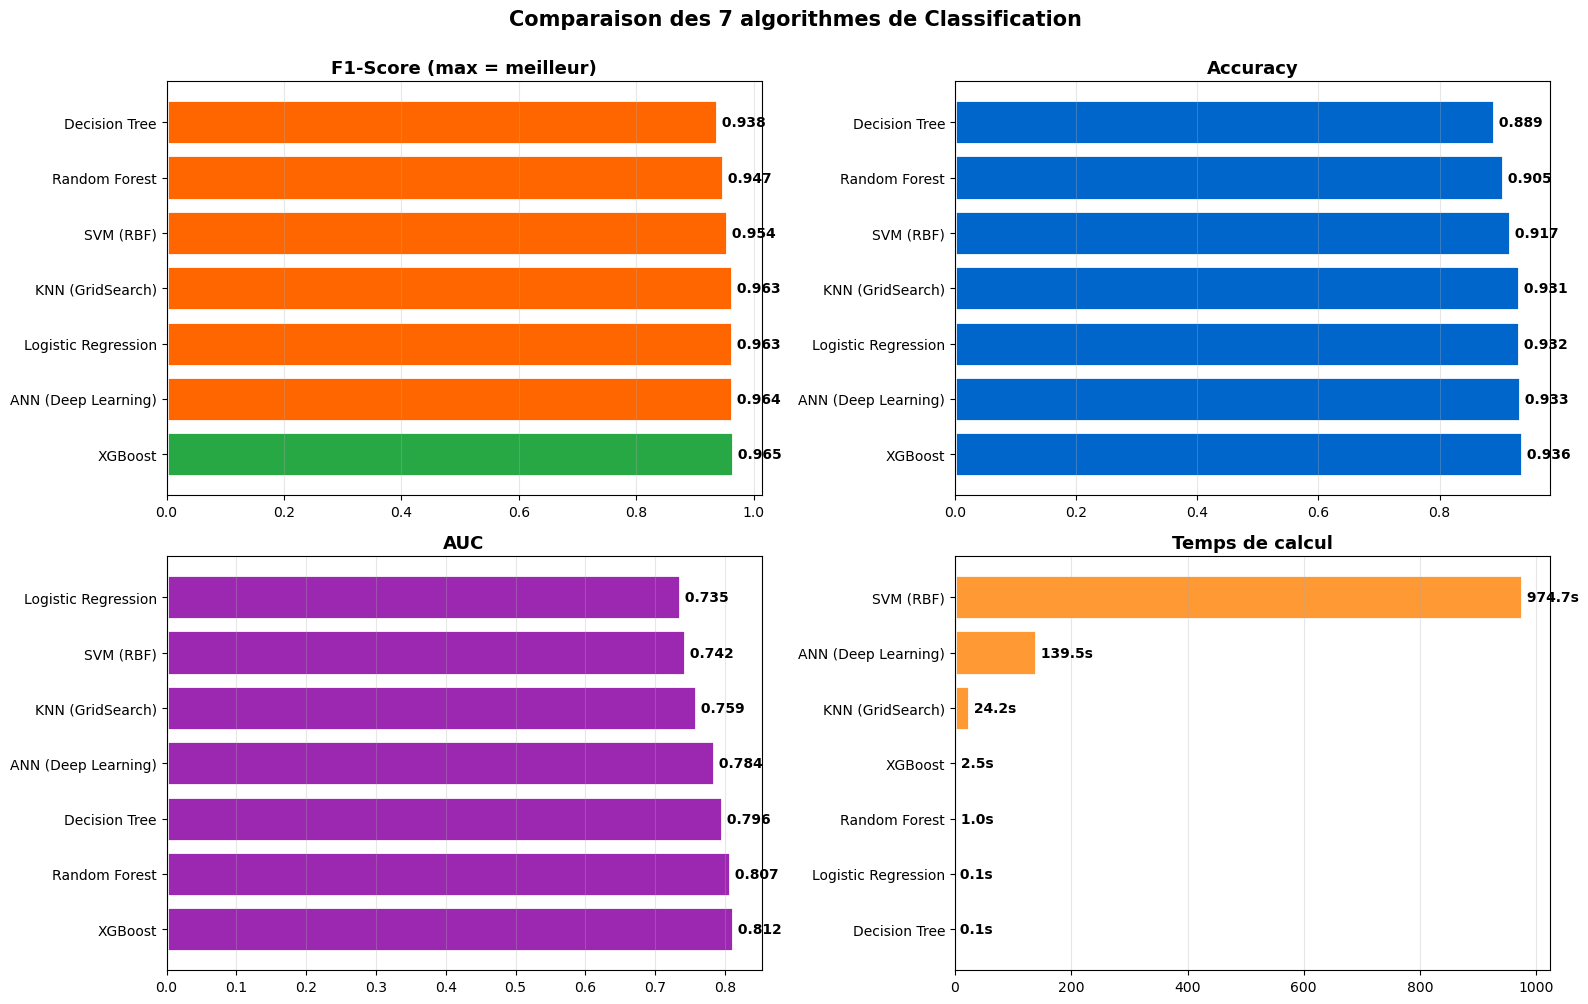

In [16]:
# === VISUALISATION COMPARATIVE ===

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# F1-Score
df_sorted_f1 = df_results_clf.sort_values('F1', ascending=False)
colors_f1 = [COLOR_GREEN if i == 0 else COLOR_ORANGE for i in range(len(df_sorted_f1))]
axes[0, 0].barh(df_sorted_f1['Algorithme'], df_sorted_f1['F1'], color=colors_f1, edgecolor='white', linewidth=2)
for i, val in enumerate(df_sorted_f1['F1']):
    axes[0, 0].text(val, i, f' {val:.3f}', va='center', fontweight='bold')
axes[0, 0].set_title('F1-Score (max = meilleur)', fontsize=13, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Accuracy
df_sorted_acc = df_results_clf.sort_values('Accuracy', ascending=False)
axes[0, 1].barh(df_sorted_acc['Algorithme'], df_sorted_acc['Accuracy'], color=COLOR_BLUE, edgecolor='white', linewidth=2)
for i, val in enumerate(df_sorted_acc['Accuracy']):
    axes[0, 1].text(val, i, f' {val:.3f}', va='center', fontweight='bold')
axes[0, 1].set_title('Accuracy', fontsize=13, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# AUC
df_sorted_auc = df_results_clf.sort_values('AUC', ascending=False)
axes[1, 0].barh(df_sorted_auc['Algorithme'], df_sorted_auc['AUC'], color=COLOR_PURPLE, edgecolor='white', linewidth=2)
for i, val in enumerate(df_sorted_auc['AUC']):
    axes[1, 0].text(val, i, f' {val:.3f}', va='center', fontweight='bold')
axes[1, 0].set_title('AUC', fontsize=13, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Temps
df_sorted_t = df_results_clf.sort_values('Temps_s')
axes[1, 1].barh(df_sorted_t['Algorithme'], df_sorted_t['Temps_s'], color='#FF9933', edgecolor='white', linewidth=2)
for i, val in enumerate(df_sorted_t['Temps_s']):
    axes[1, 1].text(val, i, f' {val:.1f}s', va='center', fontweight='bold')
axes[1, 1].set_title('Temps de calcul', fontsize=13, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.suptitle('Comparaison des 7 algorithmes de Classification', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

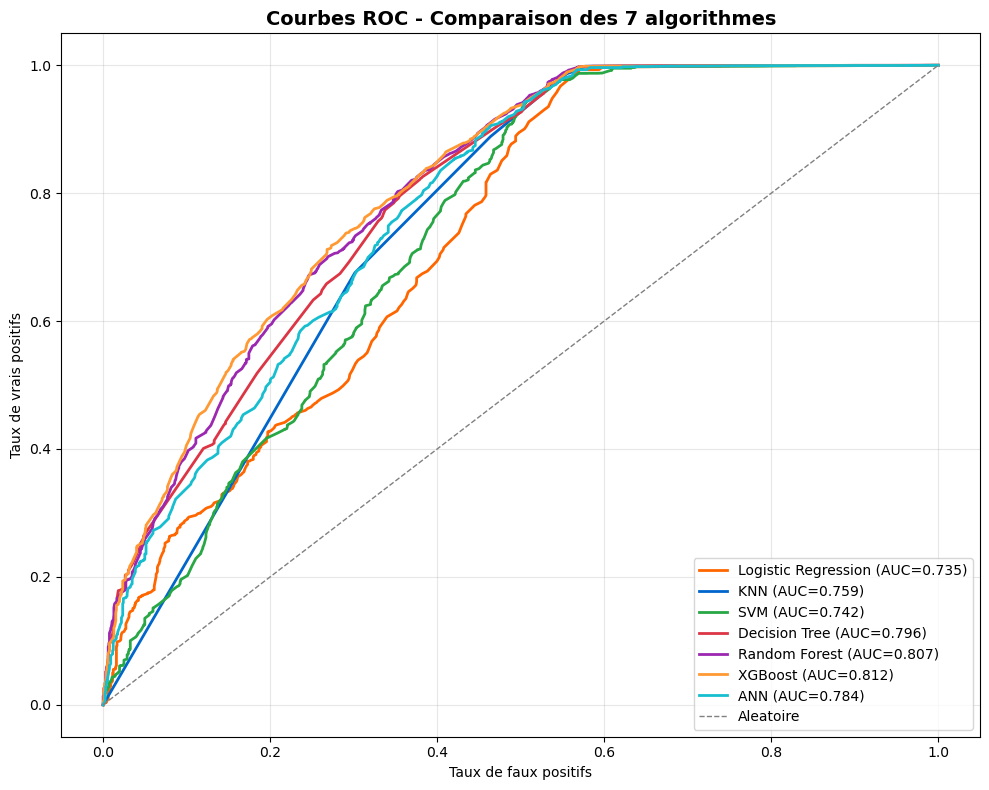

In [17]:
# === COURBES ROC COMPARATIVES ===

fig, ax = plt.subplots(figsize=(10, 8))

models_data = [
    ('Logistic Regression', y_proba_lr, COLOR_ORANGE),
    ('KNN', y_proba_knn, COLOR_BLUE),
    ('SVM', y_proba_svm, COLOR_GREEN),
    ('Decision Tree', y_proba_dt, COLOR_RED),
    ('Random Forest', y_proba_rf, COLOR_PURPLE),
    ('XGBoost', y_proba_xgb, '#FF9933'),
    ('ANN', y_proba_ann, '#17becf'),
]

for name, proba, color in models_data:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Aleatoire')

ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Taux de vrais positifs')
ax.set_title('Courbes ROC - Comparaison des 7 algorithmes', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Synthèse et Conclusions

### Comparaison des 7 algorithmes

L'algorithme retenu est celui avec le meilleur **F1-Score** 
(équilibre Precision/Recall).

### Méthodologie scientifique

- Train/Test stratifié 80/20
- 5 métriques d'évaluation
- GridSearchCV pour KNN
- Class weight balanced
- Reproductibilité (random_state=42)

### Application business

Le modèle retenu permet à Orange Tunisie de :
1. Identifier les **clients à risque**
2. **Optimiser** le recouvrement
3. **Personnaliser** les actions de relance
4. **Réduire** les pertes financières

### Améliorations possibles

- Hyperparameter tuning poussé (Bayesian Optimization)
- Cross-validation stratifiée
- SMOTE pour rééquilibrage
- Stacking de modèles
- Calibration des probabilités